# Laboratorio 1 — Análisis de Algoritmos
**Recursividad y Paradigma Divide y Vencerás**

Profesor: Santiago Suarez Cortes  
Documento: 1027660371

---
## Arreglos de trabajo

Construidos a partir de la cédula **1027660371**.  
Los ceros se reemplazan por el último dígito → **1**.

- **A1** (subarreglo máximo): `[1, -1, 2, -7, 6, -6, 1, -3, 7, -1]`
- **A2** (ordenamiento): `[1, 1, 2, 7, 6, 6, 1, 3, 7, 1]`

In [3]:
A1 = [1, -1, 2, -7, 6, -6, 1, -3, 7, -1]
A2 = [1,  1, 2,  7, 6,  6, 1,  3, 7,  1]

print("A1:", A1)
print("A2:", A2)

A1: [1, -1, 2, -7, 6, -6, 1, -3, 7, -1]
A2: [1, 1, 2, 7, 6, 6, 1, 3, 7, 1]


---
## Ejercicio 3 — Subarreglo Máximo
### Algoritmo de Fuerza Bruta — O(n²)

In [4]:
def max_subarray_bruta(arr):
    n = len(arr)
    max_suma = float('-inf')
    mejor = (0, 0)
    for i in range(n):
        s = 0
        for j in range(i, n):
            s += arr[j]
            if s > max_suma:
                max_suma = s
                mejor = (i, j)
    return mejor[0], mejor[1], max_suma

li, hi, s = max_subarray_bruta(A1)
print(f"Subarreglo máximo: {A1[li:hi+1]}  |  suma = {s}  |  índices ({li}, {hi})")

Subarreglo máximo: [7]  |  suma = 7  |  índices (8, 8)


### Algoritmo Divide y Vencerás — O(n log n)

In [5]:
def max_cruzado(arr, low, mid, high):
    # Desde el centro hacia la izquierda
    left_sum = float('-inf')
    s = 0
    max_left = mid
    for i in range(mid, low - 1, -1):
        s += arr[i]
        if s > left_sum:
            left_sum = s
            max_left = i

    # Desde el centro hacia la derecha
    right_sum = float('-inf')
    s = 0
    max_right = mid + 1
    for j in range(mid + 1, high + 1):
        s += arr[j]
        if s > right_sum:
            right_sum = s
            max_right = j

    return max_left, max_right, left_sum + right_sum


def max_subarray_dc(arr, low, high):
    # Caso base
    if low == high:
        return low, high, arr[low]

    mid = (low + high) // 2

    ll, lh, ls = max_subarray_dc(arr, low, mid)       # izquierda
    rl, rh, rs = max_subarray_dc(arr, mid + 1, high)  # derecha
    cl, ch, cs = max_cruzado(arr, low, mid, high)      # cruzado

    if ls >= rs and ls >= cs:
        return ll, lh, ls
    elif rs >= ls and rs >= cs:
        return rl, rh, rs
    else:
        return cl, ch, cs


li, hi, s = max_subarray_dc(A1, 0, len(A1) - 1)
print(f"Subarreglo máximo: {A1[li:hi+1]}  |  suma = {s}  |  índices ({li}, {hi})")

Subarreglo máximo: [7]  |  suma = 7  |  índices (8, 8)


### Comparación de tiempos — Subarreglo Máximo

In [6]:
import time
import random
import matplotlib.pyplot as plt
import seaborn as sns

def medir_tiempo(func, *args, reps=5):
    tiempos = []
    for _ in range(reps):
        t0 = time.perf_counter()
        func(*args)
        tiempos.append(time.perf_counter() - t0)
    return (sum(tiempos) / len(tiempos)) * 1000  # en ms


tamaños = [10, 50, 100, 200, 500, 1000]
t_bruta, t_dc = [], []

random.seed(42)
for n in tamaños:
    arr = [random.randint(-100, 100) for _ in range(n)]
    t_bruta.append(medir_tiempo(max_subarray_bruta, arr))
    t_dc.append(medir_tiempo(max_subarray_dc, arr, 0, n - 1))

print(f"{'n':>6}  {'Fuerza Bruta (ms)':>20}  {'Divide y Vencerás (ms)':>24}")
print("-" * 55)
for n, tb, td in zip(tamaños, t_bruta, t_dc):
    print(f"{n:>6}  {tb:>20.4f}  {td:>24.4f}")

     n     Fuerza Bruta (ms)    Divide y Vencerás (ms)
-------------------------------------------------------
    10                0.0060                    0.0138
    50                0.0702                    0.0723
   100                0.2497                    0.1499
   200                0.9884                    0.3189
   500                6.4820                    0.8313
  1000               26.3086                    1.6989


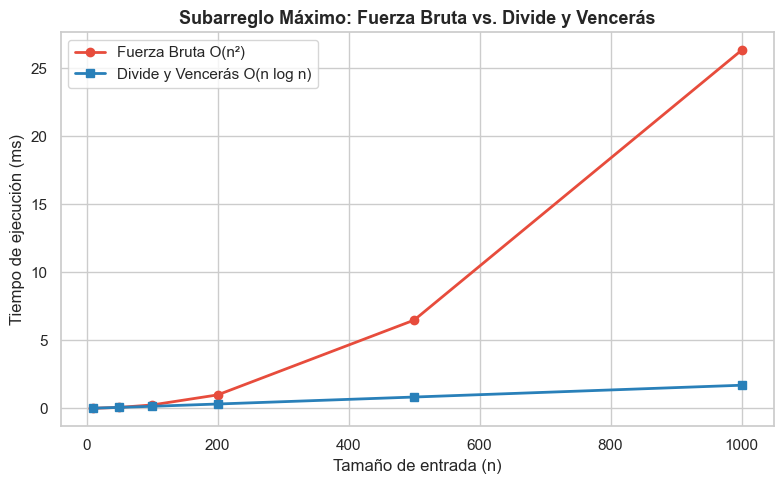

Gráfica guardada como grafica_subarreglo.png


In [7]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(tamaños, t_bruta, marker='o', label='Fuerza Bruta O(n²)', color='#e74c3c', linewidth=2)
ax.plot(tamaños, t_dc,    marker='s', label='Divide y Vencerás O(n log n)', color='#2980b9', linewidth=2)

ax.set_xlabel('Tamaño de entrada (n)', fontsize=12)
ax.set_ylabel('Tiempo de ejecución (ms)', fontsize=12)
ax.set_title('Subarreglo Máximo: Fuerza Bruta vs. Divide y Vencerás', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('grafica_subarreglo.png', dpi=150)
plt.show()
print("Gráfica guardada como grafica_subarreglo.png")

---
## Ejercicio 4 — Merge Sort vs. Insertion Sort
### Implementaciones

In [8]:
def mezclar(izq, der):
    resultado = []
    i = j = 0
    while i < len(izq) and j < len(der):
        if izq[i] <= der[j]:
            resultado.append(izq[i]); i += 1
        else:
            resultado.append(der[j]); j += 1
    resultado.extend(izq[i:])
    resultado.extend(der[j:])
    return resultado


def merge_sort(arr):
    if len(arr) <= 1:
        return arr
    mid = len(arr) // 2
    izq = merge_sort(arr[:mid])
    der = merge_sort(arr[mid:])
    return mezclar(izq, der)


def insertion_sort(arr):
    arr = arr[:]
    for i in range(1, len(arr)):
        clave = arr[i]
        j = i - 1
        while j >= 0 and arr[j] > clave:
            arr[j + 1] = arr[j]
            j -= 1
        arr[j + 1] = clave
    return arr


# Verificación con A2
print("Merge Sort A2:    ", merge_sort(A2))
print("Insertion Sort A2:", insertion_sort(A2))

Merge Sort A2:     [1, 1, 1, 1, 2, 3, 6, 6, 7, 7]
Insertion Sort A2: [1, 1, 1, 1, 2, 3, 6, 6, 7, 7]


### Comparación de tiempos — Ordenamiento

In [9]:
tamaños_sort = [10, 50, 100, 500, 1000, 5000]
t_merge, t_insertion = [], []

random.seed(42)
for n in tamaños_sort:
    arr = [random.randint(-1000, 1000) for _ in range(n)]
    t_insertion.append(medir_tiempo(insertion_sort, arr))
    t_merge.append(medir_tiempo(merge_sort, arr))

print(f"{'n':>6}  {'Insertion Sort (ms)':>22}  {'Merge Sort (ms)':>18}")
print("-" * 52)
for n, ti, tm in zip(tamaños_sort, t_insertion, t_merge):
    print(f"{n:>6}  {ti:>22.4f}  {tm:>18.4f}")

     n     Insertion Sort (ms)     Merge Sort (ms)
----------------------------------------------------
    10                  0.0041              0.0113
    50                  0.0534              0.0597
   100                  0.1921              0.1422
   500                  4.9500              0.9739
  1000                 20.9006              1.8144
  5000                543.5434             11.4713


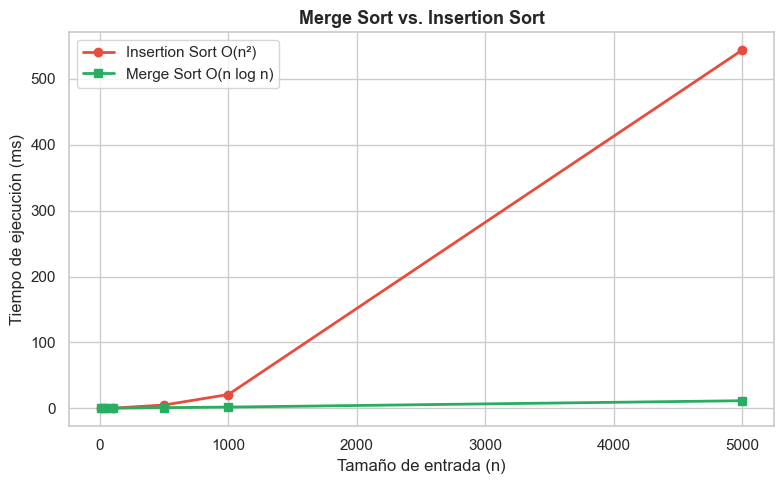

Gráfica guardada como grafica_sorting.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(tamaños_sort, t_insertion, marker='o', label='Insertion Sort O(n²)', color='#e74c3c', linewidth=2)
ax.plot(tamaños_sort, t_merge,     marker='s', label='Merge Sort O(n log n)', color='#27ae60', linewidth=2)

ax.set_xlabel('Tamaño de entrada (n)', fontsize=12)
ax.set_ylabel('Tiempo de ejecución (ms)', fontsize=12)
ax.set_title('Merge Sort vs. Insertion Sort', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('grafica_sorting.png', dpi=150)
plt.show()
print("Gráfica guardada como grafica_sorting.png")